<a href="https://colab.research.google.com/github/nunez1405/Data-science-projects/blob/main/Heart.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("imnikhilanand/heart-attack-prediction")

print("Path to dataset files:", path)

100%|██████████| 2.61k/2.61k [00:00<00:00, 4.27MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/imnikhilanand/heart-attack-prediction/versions/1


In [ ]:
import os

# List all files and directories in the path
files_and_dirs = os.listdir(path)

csv_file_path = None

# Iterate to find the CSV file
for item in files_and_dirs:
    if item.endswith('.csv'):
        csv_file_path = os.path.join(path, item)
        break

if csv_file_path:
    print(f"Identified CSV file: {csv_file_path}")
else:
    print("No CSV file found in the directory.")

Identified CSV file: /root/.cache/kagglehub/datasets/imnikhilanand/heart-attack-prediction/versions/1/data.csv


## Cargar a DataFrame

### Subtask:
Utilizar la biblioteca pandas para cargar el archivo CSV identificado en un DataFrame, asegurándose de que los datos estén correctamente estructurados para su manipulación.


In [ ]:
import pandas as pd

# Load the CSV file into a pandas DataFrame
df_heart_attack = pd.read_csv(csv_file_path)

df_heart_attack

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,28,1,2,130,132,0,2,185,0,0.0,?,?,?,0
1,29,1,2,120,243,0,0,160,0,0.0,?,?,?,0
2,29,1,2,140,?,0,0,170,0,0.0,?,?,?,0
3,30,0,1,170,237,0,1,170,0,0.0,?,?,6,0
4,31,0,2,100,219,0,1,150,0,0.0,?,?,?,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
289,52,1,4,160,331,0,0,94,1,2.5,?,?,?,1
290,54,0,3,130,294,0,1,100,1,0.0,2,?,?,1
291,56,1,4,155,342,1,0,150,1,3.0,2,?,?,1
292,58,0,2,180,393,0,0,110,1,1.0,2,?,7,1


Repasemos lo que es visualizacion de datos:


In [ ]:
for col in df_heart_attack.columns:
    print(f"{col}: {df_heart_attack[col].nunique()}")

age: 38
sex: 2
cp: 4
trestbps: 32
chol: 154
fbs: 3
restecg: 4
thalach: 72
exang: 3
oldpeak: 10
slope: 4
ca: 2
thal: 4
num       : 2


In [ ]:
import numpy as np
df_heart_attack = df_heart_attack.apply(pd.to_numeric, errors='coerce')
df_heart_attack.fillna({col: df_heart_attack[col].median() for col in df_heart_attack.columns if df_heart_attack[col].dtype != "object"}, inplace=True)
df_heart_attack.replace("?", np.nan, inplace=True)

In [ ]:
for col in df_heart_attack.columns:
    print(f"{col}: {df_heart_attack[col].nunique()}")

age: 38
sex: 2
cp: 4
trestbps: 31
chol: 153
fbs: 2
restecg: 3
thalach: 71
exang: 2
oldpeak: 10
slope: 3
ca: 1
thal: 3
num       : 2


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pickle


In [ ]:
df_heart_attack.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 294 entries, 0 to 293
Data columns (total 14 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   age         294 non-null    int64  
 1   sex         294 non-null    int64  
 2   cp          294 non-null    int64  
 3   trestbps    294 non-null    float64
 4   chol        294 non-null    float64
 5   fbs         294 non-null    float64
 6   restecg     294 non-null    float64
 7   thalach     294 non-null    float64
 8   exang       294 non-null    float64
 9   oldpeak     294 non-null    float64
 10  slope       294 non-null    float64
 11  ca          294 non-null    float64
 12  thal        294 non-null    float64
 13  num         294 non-null    int64  
dtypes: float64(10), int64(4)
memory usage: 32.3 KB


In [ ]:
df_heart_attack.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
count,294.000000,294.000000,294.000000,294.000000,294.000000,294.000000,294.000000,294.000000,294.000000,294.000000,294.000000,294.0,294.000000,294.000000
mean,47.826531,0.724490,2.982993,132.574830,250.234694,0.068027,0.217687,139.132653,0.302721,0.586054,1.962585,0.0,5.965986,0.360544
std,7.811812,0.447533,0.965117,17.597108,64.982245,0.252222,0.460257,23.549514,0.460219,0.908648,0.207277,0.0,0.501397,0.480977
min,28.000000,0.000000,1.000000,92.000000,85.000000,0.000000,0.000000,82.000000,0.000000,0.000000,1.000000,0.0,3.000000,0.000000
25%,42.000000,0.000000,2.000000,120.000000,211.250000,0.000000,0.000000,122.000000,0.000000,0.000000,2.000000,0.0,6.000000,0.000000
50%,49.000000,1.000000,3.000000,130.000000,243.000000,0.000000,0.000000,140.000000,0.000000,0.000000,2.000000,0.0,6.000000,0.000000
75%,54.000000,1.000000,4.000000,140.000000,277.000000,0.000000,0.000000,155.000000,1.000000,1.000000,2.000000,0.0,6.000000,1.000000
max,66.000000,1.000000,4.000000,200.000000,603.000000,1.000000,2.000000,190.000000,1.000000,5.000000,3.000000,0.0,7.000000,1.000000


In [ ]:
X = df_heart_attack.drop("num       ", axis=1)
y = (df_heart_attack["num       "] > 0).astype(int)

In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
import pickle

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

Es importante Stratify porque con Stratify, Scikit-learn se asegura de que la proporción de las clases se mantenga idéntica tanto en el set de entrenamiento como en el de pruebas

In [ ]:
print("Train shape:", X_train.shape)
print("Test shape :", X_test.shape)
print("\nLabel distribution (train):")
print(y_train.value_counts())
print("\nLabel distribution (test):")
print(y_test.value_counts())

Train shape: (235, 13)
Test shape : (59, 13)

Label distribution (train):
num       
0    150
1     85
Name: count, dtype: int64

Label distribution (test):
num       
0    38
1    21
Name: count, dtype: int64


In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
scaler = StandardScaler()


In [ ]:
pipeline = Pipeline([
    ('scaler', scaler),
    ('classifier', RandomForestClassifier(random_state=42))
])

In [ ]:
pipeline.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('classifier', RandomForestClassifier(random_state=42))])

              precision    recall  f1-score   support

           0       0.89      0.89      0.89        38
           1       0.81      0.81      0.81        21

    accuracy                           0.86        59
   macro avg       0.85      0.85      0.85        59
weighted avg       0.86      0.86      0.86        59



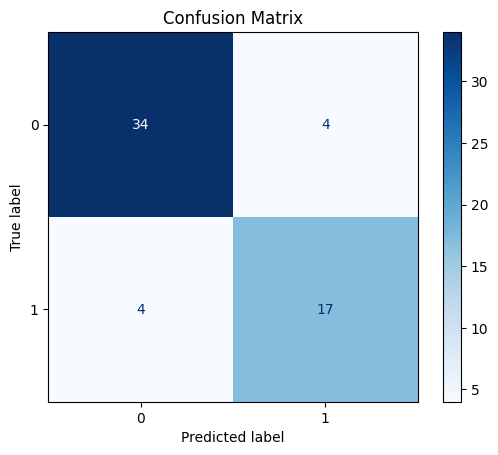

In [ ]:
y_pred = pipeline.predict(X_test)
print(classification_report(y_test, y_pred))

ConfusionMatrixDisplay.from_estimator(pipeline, X_test, y_test, cmap='Blues')
plt.title('Confusion Matrix')
plt.show()

Ahora probaremos con Logistic Classification

In [ ]:
from sklearn.linear_model import LogisticRegression
pipeline2 = Pipeline([
    ('scaler', scaler),
    ('classifier', LogisticRegression(random_state=42))
])

pipeline2.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('classifier', LogisticRegression(random_state=42))])

              precision    recall  f1-score   support

           0       0.89      0.89      0.89        38
           1       0.81      0.81      0.81        21

    accuracy                           0.86        59
   macro avg       0.85      0.85      0.85        59
weighted avg       0.86      0.86      0.86        59



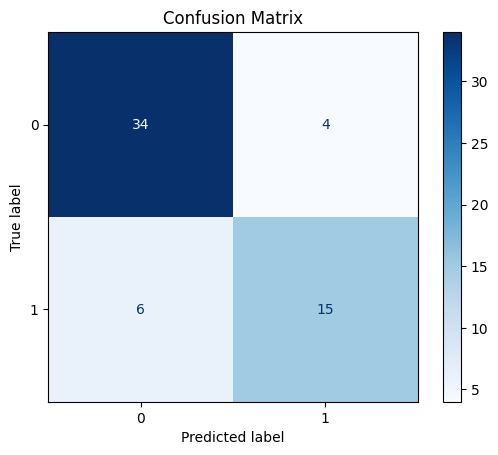

In [ ]:
y_pred_2 = pipeline2.predict(X_test)
print(classification_report(y_test, y_pred))

ConfusionMatrixDisplay.from_estimator(pipeline2, X_test, y_test, cmap='Blues')
plt.title('Confusion Matrix')
plt.show()